# 08b — Noisy LJ: closing the 8D propagator-to-AE gap

Freeze one 8D displacement autoencoder, select the latent propagator using validation rollout p-ratio R², evaluate the selected model once on held-out trajectories, and analyze what the eight latent coordinates encode.

In [11]:
%matplotlib inline
from pathlib import Path
import importlib
import os
import sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from graph_utils import calc_p_ratio_rollout_sides, directional_side_indices_from_box

ROOT = next(path for path in [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]] if (path/'src/lss').exists())
for path in [ROOT, ROOT/'src']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from lss.data import load_dataset
from lss.graph import clone_graph
from lss.latent.capacity import experiment_config_fingerprint
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import r2_score
from lss.latent.training import decode_latent_to_graph
from lss.utils import resolve_device
from lss.plotting import PAPER_COLORS, apply_editorial_style
from scripts.quick_lj_frozen_ae_propagator_sweep import encode_latent_table, evaluate
from scripts.tune_lj_z3_delta_propagator import DeltaMLP
import scripts.train_lj_four_step_latent_propagator as propagator_helper
propagator_helper = importlib.reload(propagator_helper)

apply_editorial_style()
DEVICE = torch.device(resolve_device('auto'))
DEVICE

device(type='cuda')

In [12]:
SEED = 6756435
MODEL_SEED = SEED + 8100
FORCE_TRAIN_AE = False
FORCE_TRAIN_PROPAGATORS = False

DATA = ROOT/'data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_500sims_200frames.pt'
OUTPUT = ROOT/'notebooks/results/08b_lj_8d_propagator_and_latent_analysis'
OUTPUT.mkdir(parents=True, exist_ok=True)

AE_CONFIG = {
    'train_count': 300, 'val_count': 100,
    'latent_dim': 8, 'latent_tokens': 32, 'hidden_size': 64,
    'batch_graphs': 256, 'ae_max_train_frames_per_sim': 150,
    'ae_max_epochs': 20, 'ae_patience': 4,
    'ae_lr': 3.5e-4, 'ae_weight_decay': 1e-5,
    'node_feature_mode': 'normalized_delta', 'ae_target_mode': 'normalized_delta',
}
SPLIT_CONFIG = {
    'validation_start': 350, 'validation_count': 50,
    'test_start': 400, 'test_count': 100,
    'final_step': 199, 'latent_encode_batch_size': 24,
}
TARGET_STEP = 100

# A compact, validation-only search around the successful fixed-history delta-z model.
PROPAGATOR_CANDIDATES = [
    {'name': 'k06_u1_h64',  'observed_frames': (1, 6),  'unroll_steps': 1, 'hidden_size': 64,  'depth': 2, 'learning_rate': 2e-4},
    {'name': 'k08_u1_h64',  'observed_frames': (1, 8),  'unroll_steps': 1, 'hidden_size': 64,  'depth': 2, 'learning_rate': 2e-4},
    {'name': 'k10_u1_h64',  'observed_frames': (1, 10), 'unroll_steps': 1, 'hidden_size': 64,  'depth': 2, 'learning_rate': 2e-4},
    {'name': 'k12_u1_h64',  'observed_frames': (1, 12), 'unroll_steps': 1, 'hidden_size': 64,  'depth': 2, 'learning_rate': 2e-4},
    {'name': 'k08_u4_h128', 'observed_frames': (1, 8),  'unroll_steps': 4, 'hidden_size': 128, 'depth': 3, 'learning_rate': 1e-4},
    {'name': 'k10_u4_h128', 'observed_frames': (1, 10), 'unroll_steps': 4, 'hidden_size': 128, 'depth': 3, 'learning_rate': 1e-4},
    {'name': 'k12_u4_h128', 'observed_frames': (1, 12), 'unroll_steps': 4, 'hidden_size': 128, 'depth': 3, 'learning_rate': 1e-4},
    {'name': 'k10_u8_h128', 'observed_frames': (1, 10), 'unroll_steps': 8, 'hidden_size': 128, 'depth': 3, 'learning_rate': 1e-4},
    {'name': 'full199_vskip_k12_u1_h64', 'observed_frames': (1, 12), 'unroll_steps': 1,
     'hidden_size': 64, 'depth': 2, 'learning_rate': 2e-4, 'target_step': 199,
     'history_mode': 'fixed_velocity_residual', 'rollout_eval_horizons': (50, 100, 150, 199)},
    {'name': 'full199_vskip_k12_u1_h64_lr1e4', 'observed_frames': (1, 12), 'unroll_steps': 1,
     'hidden_size': 64, 'depth': 2, 'learning_rate': 1e-4, 'target_step': 199,
     'history_mode': 'fixed_velocity_residual', 'rollout_eval_horizons': (50, 100, 150, 199)},
    {'name': 'full199_vskip_k12_u1_h64_lr5e5', 'observed_frames': (1, 12), 'unroll_steps': 1,
     'hidden_size': 64, 'depth': 2, 'learning_rate': 5e-5, 'target_step': 199,
     'history_mode': 'fixed_velocity_residual', 'rollout_eval_horizons': (50, 100, 150, 199)},
]
PROPAGATOR_DEFAULTS = {
    'target_step': TARGET_STEP, 'weight_decay': 1e-5,
    'max_epochs': 60, 'early_stop_patience': 10, 'batch_size': 256,
    'early_stop_min_delta': 1e-4, 'rollout_eval_every': 2,
    'history_mode': 'fixed_latent_frames', 'checkpoint_metric': 'val_rollout_p_ratio_r2',
}
assert DATA.exists(), DATA
if FORCE_TRAIN_AE and not FORCE_TRAIN_PROPAGATORS:
    raise ValueError('A retrained AE changes the latent coordinates; also set FORCE_TRAIN_PROPAGATORS=True.')
assert AE_CONFIG['train_count'] <= SPLIT_CONFIG['validation_start']
assert SPLIT_CONFIG['validation_start'] + SPLIT_CONFIG['validation_count'] <= SPLIT_CONFIG['test_start']
print({'device': str(DEVICE), 'AE': AE_CONFIG, 'split': SPLIT_CONFIG, 'candidate_count': len(PROPAGATOR_CANDIDATES)})

{'device': 'cuda', 'AE': {'train_count': 300, 'val_count': 100, 'latent_dim': 8, 'latent_tokens': 32, 'hidden_size': 64, 'batch_graphs': 256, 'ae_max_train_frames_per_sim': 150, 'ae_max_epochs': 20, 'ae_patience': 4, 'ae_lr': 0.00035, 'ae_weight_decay': 1e-05, 'node_feature_mode': 'normalized_delta', 'ae_target_mode': 'normalized_delta'}, 'split': {'validation_start': 350, 'validation_count': 50, 'test_start': 400, 'test_count': 100, 'final_step': 199, 'latent_encode_batch_size': 24}, 'candidate_count': 11}


## Frozen 8D autoencoder and disjoint latent tables

In [13]:
AE_IDENTITY = {
    'seed': SEED, 'AE': AE_CONFIG, 'model': 'single_stage_attention',
    'edge_mode': 'stored', 'edge_multiplicity': 1, 'edge_vector_dim': 8,
}
AE_TAG = experiment_config_fingerprint(AE_IDENTITY)
LOCAL_AE_BUNDLE = OUTPUT/f'ae_8d_{AE_TAG}.pt'
LOCAL_LATENT_CACHE = OUTPUT/f'latents_8d_{AE_TAG}_frame{SPLIT_CONFIG["final_step"]}.pt'
SHARED_08_ROOT = ROOT/'notebooks/results/08_history_aware_latent_rollout/lj_noisy/direct4_displacement_ae_rolling_latent_history'
SHARED_08_AE = SHARED_08_ROOT/'latent_dimension_comparison/e1fa41661fd5_47f1125cd44c/latent_8/ae_bundle.pt'
SHARED_08_LATENTS = SHARED_08_AE.with_name(f'encoded_latents_frame{SPLIT_CONFIG["final_step"]}.pt')
# Reuse the exact successful 8D representation from 08. A forced AE run is isolated in 08b.
AE_BUNDLE = LOCAL_AE_BUNDLE if FORCE_TRAIN_AE or not SHARED_08_AE.exists() else SHARED_08_AE
LATENT_CACHE = LOCAL_LATENT_CACHE if FORCE_TRAIN_AE or not SHARED_08_LATENTS.exists() else SHARED_08_LATENTS
if AE_BUNDLE == SHARED_08_AE:
    shared_params = torch.load(SHARED_08_AE, map_location='cpu', weights_only=False)['params']
    shared_keys = ['train_count', 'val_count', 'latent_dim', 'latent_tokens', 'hidden_size', 'batch_graphs', 'ae_max_train_frames_per_sim', 'ae_max_epochs', 'ae_patience', 'ae_lr', 'ae_weight_decay', 'node_feature_mode', 'ae_target_mode', 'split_seed']
    expected_shared = {**AE_CONFIG, 'split_seed': SEED}
    mismatches = {key: (expected_shared[key], shared_params.get(key)) for key in shared_keys if expected_shared[key] != shared_params.get(key)}
    if mismatches:
        raise ValueError(f'Shared 08 8D AE configuration mismatch: {mismatches}')
ae_cfg = {
    'dataset_name': 'lj_noisy', 'split_seed': SEED, 'model_seed': SEED,
    'device': str(DEVICE), 'split_stratify_temperature': False, 'min_train_p_ratio': None,
    'pos_dim': 2, 'frame_skip': 1, 'train_frame_start_order': 0,
    'edge_multiplicity': 1, 'edge_vector_dim': 8, 'edge_mode': 'stored',
    'autoencoder_model': 'single_stage_attention', 'early_stop_min_delta': 1e-5,
    'should_rollout': False, 'should_train_propagator': False,
    'cache_path': str(AE_BUNDLE), 'force_train': FORCE_TRAIN_AE, **AE_CONFIG,
}
source = {**ae_cfg, 'source_name': 'Noisy LJ', 'label': 'Noisy LJ | focused 8D AE', 'path': str(DATA)}
seed_everything(SEED)
ae_result = run_latent_experiment(source, ae_cfg, device=DEVICE)
ae, normalizers, ae_params = ae_result['ae'], ae_result['normalizers'], ae_result['params']
for parameter in ae.parameters():
    parameter.requires_grad_(False)
ae.eval()

all_sims = load_dataset(DATA, edge_multiplicity=1, edge_vector_dim=8)
generator = torch.Generator().manual_seed(int(ae_params['split_seed']))
order = torch.randperm(len(all_sims), generator=generator).tolist()
train_ids = order[:int(ae_params['train_count'])]
val_ids = order[SPLIT_CONFIG['validation_start']:SPLIT_CONFIG['validation_start'] + SPLIT_CONFIG['validation_count']]
test_ids = order[SPLIT_CONFIG['test_start']:SPLIT_CONFIG['test_start'] + SPLIT_CONFIG['test_count']]
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
train_sims = [all_sims[index] for index in train_ids]
val_sims = [all_sims[index] for index in val_ids]
test_sims = [all_sims[index] for index in test_ids]
sims = train_sims + val_sims + test_sims
expected_shape = (len(sims), SPLIT_CONFIG['final_step'] + 1, AE_CONFIG['latent_dim'])
if LATENT_CACHE.exists() and not FORCE_TRAIN_AE:
    latent_table = torch.load(LATENT_CACHE, map_location='cpu', weights_only=True)
    if tuple(latent_table.shape) != expected_shape:
        print(f'Re-encoding stale latent cache {tuple(latent_table.shape)}; expected {expected_shape}.')
        latent_table = encode_latent_table(ae, normalizers, sims, max_frame=SPLIT_CONFIG['final_step'], batch_size=SPLIT_CONFIG['latent_encode_batch_size'], device=DEVICE, node_feature_mode=ae_params['node_feature_mode'])
        torch.save(latent_table, LATENT_CACHE)
else:
    latent_table = encode_latent_table(ae, normalizers, sims, max_frame=SPLIT_CONFIG['final_step'], batch_size=SPLIT_CONFIG['latent_encode_batch_size'], device=DEVICE, node_feature_mode=ae_params['node_feature_mode'])
    torch.save(latent_table, LATENT_CACHE)
train_stop = len(train_sims)
val_stop = train_stop + len(val_sims)
train_z, val_z, test_z = latent_table[:train_stop], latent_table[train_stop:val_stop], latent_table[val_stop:]
print({'train_z': tuple(train_z.shape), 'val_z': tuple(val_z.shape), 'test_z': tuple(test_z.shape), 'AE_cache': str(AE_BUNDLE)})

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_history_aware_latent_rollout/lj_noisy/direct4_displacement_ae_rolling_latent_history/latent_dimension_comparison/e1fa41661fd5_47f1125cd44c/latent_8/ae_bundle.pt
{'train_z': (300, 200, 8), 'val_z': (50, 200, 8), 'test_z': (100, 200, 8), 'AE_cache': '/home/alexz/Documents/course_project/notebooks/results/08_history_aware_latent_rollout/lj_noisy/direct4_displacement_ae_rolling_latent_history/latent_dimension_comparison/e1fa41661fd5_47f1125cd44c/latent_8/ae_bundle.pt'}


In [14]:
EVALUATION_STEPS = [20, 50, 75, 100, 125, 150, 175, 199]
ae_ceiling_rows = []
for step in EVALUATION_STEPS:
    metrics = evaluate(ae, normalizers, test_sims, test_z[:, step], step, DEVICE, ae_target_mode=ae_params['ae_target_mode'])
    ae_ceiling_rows.append({'step': step, **metrics})
ae_ceiling = pd.DataFrame(ae_ceiling_rows)
display(ae_ceiling[['step', 'p_ratio_r2', 'p_ratio_pearson', 'pred_to_true_std']].round(4))

,step,p_ratio_r2,p_ratio_pearson,pred_to_true_std
0,20,0.0470,0.4247,0.6456
1,50,0.7554,0.8730,0.7909
2,75,0.8405,0.9186,0.9510
3,100,0.8529,0.9275,1.0108
4,125,0.8575,0.9316,1.0298
5,150,0.8397,0.9315,1.0580
6,175,0.7789,0.9298,1.1167
7,199,0.6590,0.9020,1.1073


## Validation-only propagator search

In [15]:
def build_model(config):
    input_dim = (1 + len(config['observed_frames'])) * AE_CONFIG['latent_dim'] + 1
    return DeltaMLP(input_dim, AE_CONFIG['latent_dim'], config['hidden_size'], config['depth']).to(DEVICE)

def rollout_latents(model, stats, z, step, config):
    return propagator_helper.rollout(
        model, stats, z, DEVICE, step, config['history_mode'],
        progress_scale=config['target_step'], observed_frames=config['observed_frames'],
    ).cpu()

candidate_rows, candidate_artifacts = [], {}
for candidate_index, candidate in enumerate(PROPAGATOR_CANDIDATES):
    config = {**PROPAGATOR_DEFAULTS, **candidate}
    tag = experiment_config_fingerprint({'AE': AE_TAG, 'propagator': config})
    checkpoint = OUTPUT/f'propagator_{config["name"]}_{tag}.pt'
    if checkpoint.exists() and not FORCE_TRAIN_PROPAGATORS:
        saved = torch.load(checkpoint, map_location='cpu', weights_only=False)
        if saved['configuration'] != config:
            raise ValueError(f'Checkpoint configuration mismatch: {checkpoint}')
        model = build_model(config)
        model.load_state_dict(saved['model_state_dict'])
        stats = {key: value.to(DEVICE) for key, value in saved['normalization'].items()}
        best = saved['best']
    else:
        model, stats, best = propagator_helper.fit(
            ae, normalizers, train_z, val_z, val_sims, seed=MODEL_SEED + candidate_index, device=DEVICE,
            rollout_eval_every=config['rollout_eval_every'], hidden_size=config['hidden_size'], depth=config['depth'],
            learning_rate=config['learning_rate'], weight_decay=config['weight_decay'],
            unroll_steps=config['unroll_steps'], target_step=config['target_step'],
            max_epochs=config['max_epochs'], early_stop_patience=config['early_stop_patience'],
            batch_size=config['batch_size'], early_stop_min_delta=config['early_stop_min_delta'],
            history_mode=config['history_mode'], ae_target_mode=ae_params['ae_target_mode'],
            observed_frames=config['observed_frames'], checkpoint_metric=config['checkpoint_metric'],
            rollout_eval_horizons=config.get('rollout_eval_horizons'),
        )
        torch.save({
            'configuration': config, 'model_state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
            'normalization': {key: value.detach().cpu() for key, value in stats.items()},
            'best': {key: value for key, value in best.items() if key != 'state'}, 'AE_tag': AE_TAG,
        }, checkpoint)
    model.eval()
    validation_horizons = (50, 100, 150, 199)
    horizon_metrics = {}
    for horizon in validation_horizons:
        predicted_val_z = rollout_latents(model, stats, val_z, horizon, config)
        horizon_metrics[horizon] = evaluate(
            ae, normalizers, val_sims, predicted_val_z, horizon, DEVICE,
            ae_target_mode=ae_params['ae_target_mode'],
        )
    val_metrics = horizon_metrics[TARGET_STEP]
    selection_score = float(np.mean([horizon_metrics[step]['p_ratio_r2'] for step in validation_horizons]))
    candidate_rows.append({
        'name': config['name'], 'observed_frames': str(config['observed_frames']), 'unroll_steps': config['unroll_steps'],
        'hidden_size': config['hidden_size'], 'depth': config['depth'], 'learning_rate': config['learning_rate'],
        'best_epoch': best['epoch'], 'val_multi_horizon_r2': selection_score, 'val_p_ratio_r2': val_metrics['p_ratio_r2'],
        'val_p_ratio_pearson': val_metrics['p_ratio_pearson'], 'val_pred_to_true_std': val_metrics['pred_to_true_std'],
        **{f'val_p_ratio_r2_step{step}': horizon_metrics[step]['p_ratio_r2'] for step in validation_horizons},
    })
    candidate_artifacts[config['name']] = (model, stats, config)
candidate_results = pd.DataFrame(candidate_rows).sort_values('val_multi_horizon_r2', ascending=False).reset_index(drop=True)
candidate_results.to_csv(OUTPUT/'validation_propagator_search.csv', index=False)
display(candidate_results.round(4))

,name,observed_frames,unroll_steps,hidden_size,depth,learning_rate,best_epoch,val_multi_horizon_r2,val_p_ratio_r2,val_p_ratio_pearson,val_pred_to_true_std,val_p_ratio_r2_step50,val_p_ratio_r2_step100,val_p_ratio_r2_step150,val_p_ratio_r2_step199
0,full199_vskip_k12_u1_h64_lr5e5,"(1, 12)",1,64,2,0.0000,24,0.4785,0.6739,0.8309,0.9441,0.7687,0.6739,0.4335,0.0378
1,full199_vskip_k12_u1_h64,"(1, 12)",1,64,2,0.0002,2,0.4527,0.6622,0.8224,0.8883,0.7480,0.6622,0.4150,-0.0144
2,full199_vskip_k12_u1_h64_lr1e4,"(1, 12)",1,64,2,0.0001,4,0.4117,0.6306,0.8111,0.9213,0.7409,0.6306,0.3767,-0.1015
3,k12_u1_h64,"(1, 12)",1,64,2,0.0002,42,0.3334,0.5915,0.7769,0.8750,0.6796,0.5915,0.3291,-0.2665
4,k08_u4_h128,"(1, 8)",4,128,3,0.0001,12,0.3203,0.5309,0.7350,0.7400,0.5367,0.5309,0.4092,-0.1954
5,k10_u1_h64,"(1, 10)",1,64,2,0.0002,48,0.3030,0.5567,0.7661,0.8312,0.6614,0.5567,0.3253,-0.3313
6,k06_u1_h64,"(1, 6)",1,64,2,0.0002,32,0.2305,0.3449,0.5913,0.6264,0.4215,0.3449,0.2004,-0.0448
7,k08_u1_h64,"(1, 8)",1,64,2,0.0002,48,0.2229,0.5372,0.7471,0.7942,0.5960,0.5372,0.2806,-0.5224
8,k10_u4_h128,"(1, 10)",4,128,3,0.0001,18,0.1519,0.4623,0.7085,0.8760,0.6481,0.4623,0.1436,-0.6463
9,k12_u4_h128,"(1, 12)",4,128,3,0.0001,16,0.0713,0.4876,0.7380,0.9361,0.6743,0.4876,0.0492,-0.9259


Propagator selection using validation p-ratio R² only.


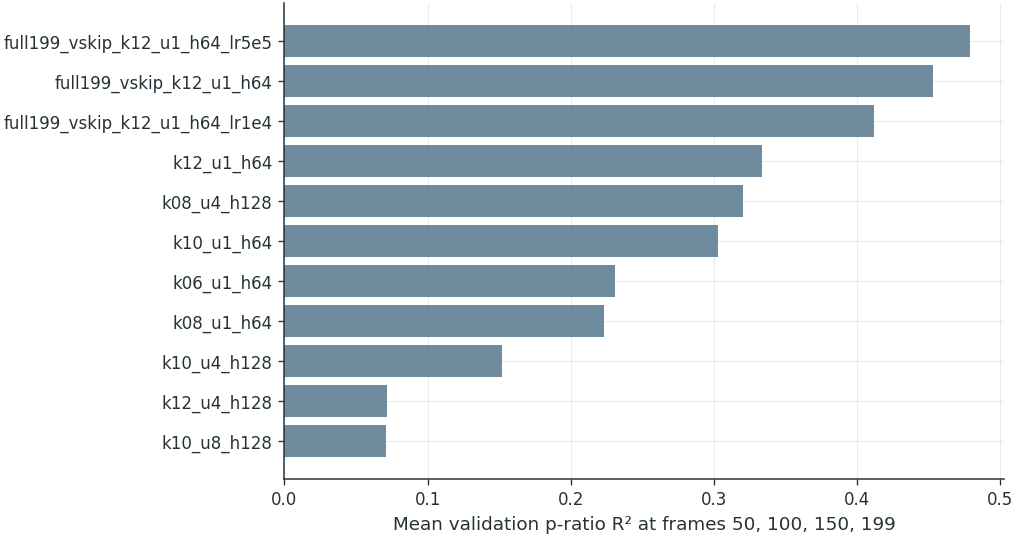

{'selected_on_validation': 'full199_vskip_k12_u1_h64_lr5e5', 'configuration': {'target_step': 199, 'weight_decay': 1e-05, 'max_epochs': 60, 'early_stop_patience': 10, 'batch_size': 256, 'early_stop_min_delta': 0.0001, 'rollout_eval_every': 2, 'history_mode': 'fixed_velocity_residual', 'checkpoint_metric': 'val_rollout_p_ratio_r2', 'name': 'full199_vskip_k12_u1_h64_lr5e5', 'observed_frames': (1, 12), 'unroll_steps': 1, 'hidden_size': 64, 'depth': 2, 'learning_rate': 5e-05, 'rollout_eval_horizons': (50, 100, 150, 199)}}


In [16]:
print('Propagator selection using validation p-ratio R² only.')
fig, ax = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
ordered = candidate_results.sort_values('val_multi_horizon_r2')
ax.barh(ordered.name, ordered.val_multi_horizon_r2.clip(lower=0), color=PAPER_COLORS['blue'], alpha=.82)
ax.set(xlabel='Mean validation p-ratio R² at frames 50, 100, 150, 199', ylabel='')
fig.savefig(OUTPUT/'validation_candidate_r2.png', dpi=240, bbox_inches='tight')
plt.show()
BEST_NAME = candidate_results.iloc[0]['name']
best_model, best_stats, best_config = candidate_artifacts[BEST_NAME]
print({'selected_on_validation': BEST_NAME, 'configuration': best_config})

## Untouched test set: AE ceiling versus selected propagator

,step,measurement,p_ratio_r2,p_ratio_pearson,n
0,20,AE ceiling,0.0470,0.4247,100
1,20,Selected propagator,-0.0052,0.3744,100
2,50,AE ceiling,0.7554,0.8730,100
3,50,Selected propagator,0.5452,0.7496,100
4,75,AE ceiling,0.8405,0.9186,100
5,75,Selected propagator,0.5735,0.7725,100
6,100,AE ceiling,0.8529,0.9275,100
7,100,Selected propagator,0.5435,0.7463,100
8,125,AE ceiling,0.8575,0.9316,100
9,125,Selected propagator,0.5019,0.7119,100


8D noisy LJ test p-ratio R²: selected propagator versus AE ceiling (full199_vskip_k12_u1_h64_lr5e5).


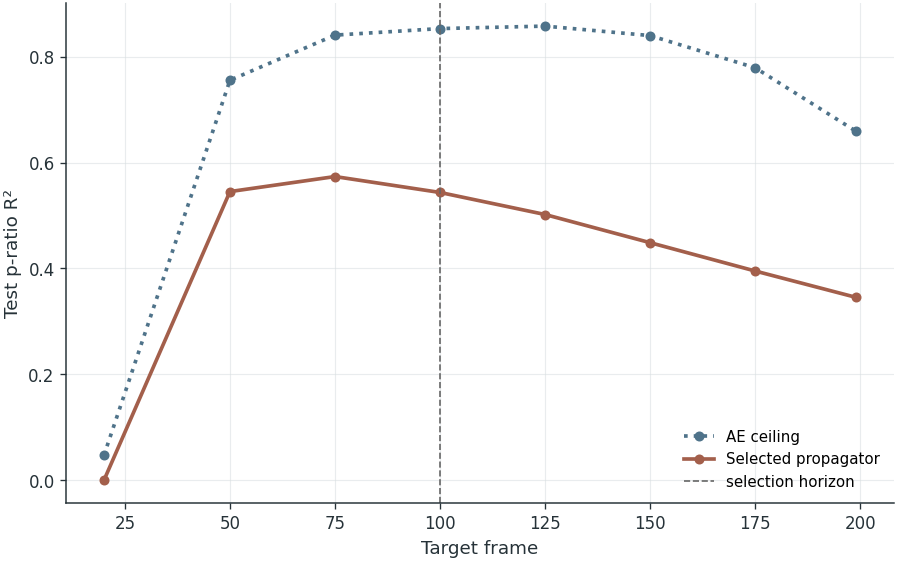

In [17]:
def p_ratio_pairs(sims, latent_values, step):
    rows = []
    with torch.no_grad():
        for sim_index, (sim, latent) in enumerate(zip(sims, latent_values)):
            graph = decode_latent_to_graph(
                ae, sim, latent.to(DEVICE), step, pos_dim=2,
                ae_target_mode=ae_params['ae_target_mode'], normalizers=normalizers, device=DEVICE,
            ).cpu()
            rows.append({
                'sim_index': sim_index, 'true_p_ratio': float(calc_p_ratio_rollout_sides(sim, step)),
                'pred_p_ratio': float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), graph], -1)),
            })
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()

test_curve_rows, test_pair_parts = [], []
for step in EVALUATION_STEPS:
    predicted_test_z = rollout_latents(best_model, best_stats, test_z, step, best_config)
    for measurement, latent_values in [('AE ceiling', test_z[:, step]), ('Selected propagator', predicted_test_z)]:
        pairs = p_ratio_pairs(test_sims, latent_values, step)
        test_pair_parts.append(pairs.assign(step=step, measurement=measurement))
        test_curve_rows.append({
            'step': step, 'measurement': measurement,
            'p_ratio_r2': r2_score(pairs.true_p_ratio, pairs.pred_p_ratio),
            'p_ratio_pearson': float(np.corrcoef(pairs.true_p_ratio, pairs.pred_p_ratio)[0, 1]), 'n': len(pairs),
        })
test_curve = pd.DataFrame(test_curve_rows)
test_pairs = pd.concat(test_pair_parts, ignore_index=True)
test_curve.to_csv(OUTPUT/'test_ae_ceiling_vs_selected_propagator.csv', index=False)
test_pairs.to_csv(OUTPUT/'test_p_ratio_pairs.csv', index=False)
display(test_curve.round(4))

print(f'8D noisy LJ test p-ratio R²: selected propagator versus AE ceiling ({BEST_NAME}).')
fig, ax = plt.subplots(figsize=(7.5, 4.7), constrained_layout=True)
for measurement, group in test_curve.groupby('measurement', sort=False):
    ax.plot(group.step, group.p_ratio_r2.clip(lower=0), marker='o', lw=2.2, ls=':' if measurement == 'AE ceiling' else '-', label=measurement)
ax.axvline(TARGET_STEP, color='0.4', ls='--', lw=1, label='selection horizon')
ax.set(xlabel='Target frame', ylabel='Test p-ratio R²')
ax.legend(frameon=False)
fig.savefig(OUTPUT/'test_r2_ceiling_vs_propagator.png', dpi=240, bbox_inches='tight')
fig.savefig(OUTPUT/'test_r2_ceiling_vs_propagator.pdf', bbox_inches='tight')
plt.show()

Test p-ratio predictions at frame 100: AE ceiling and selected propagator.


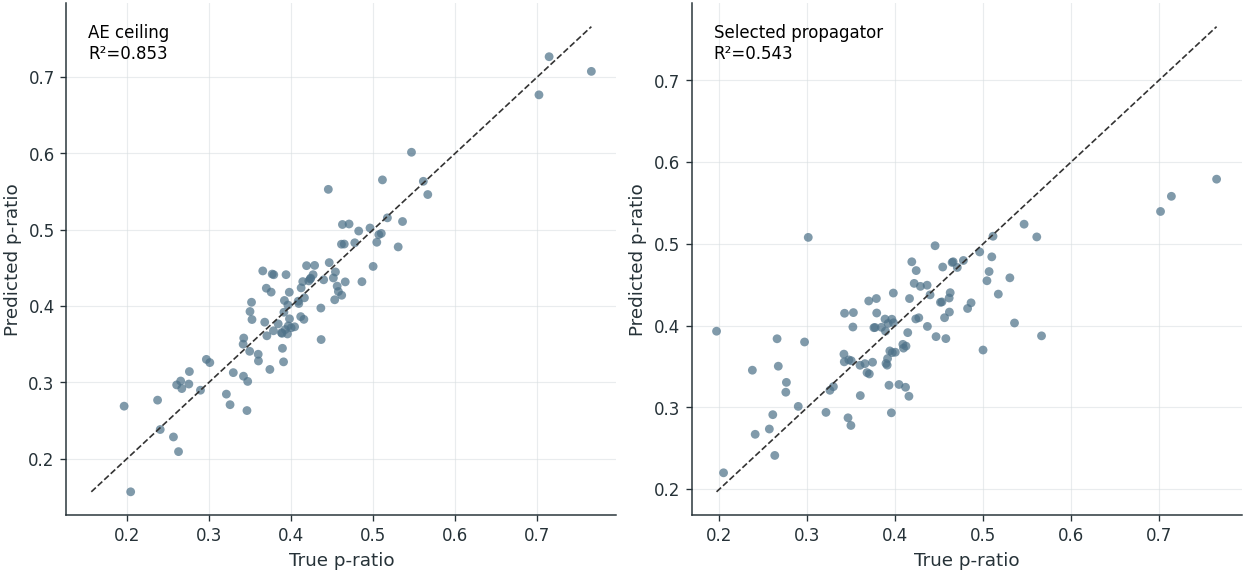

In [18]:
frame100 = test_pairs[test_pairs.step.eq(TARGET_STEP)]
print(f'Test p-ratio predictions at frame {TARGET_STEP}: AE ceiling and selected propagator.')
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8), constrained_layout=True)
for ax, measurement in zip(axes, ['AE ceiling', 'Selected propagator']):
    frame = frame100[frame100.measurement.eq(measurement)]
    true, pred = frame.true_p_ratio.to_numpy(float), frame.pred_p_ratio.to_numpy(float)
    lo, hi = min(true.min(), pred.min()), max(true.max(), pred.max())
    ax.scatter(true, pred, s=28, alpha=.72, edgecolor='none')
    ax.plot([lo, hi], [lo, hi], '--', color='0.2', lw=1)
    ax.set(xlabel='True p-ratio', ylabel='Predicted p-ratio')
    ax.text(.04, .96, f'{measurement}\nR²={r2_score(true, pred):.3f}', transform=ax.transAxes, ha='left', va='top')
fig.savefig(OUTPUT/'test_scatter_frame100.png', dpi=240, bbox_inches='tight')
plt.show()

## Network-level latent organization: one point per held-out trajectory

Network-level Pearson correlations: initial latent state, long latent change, and long latent slope.


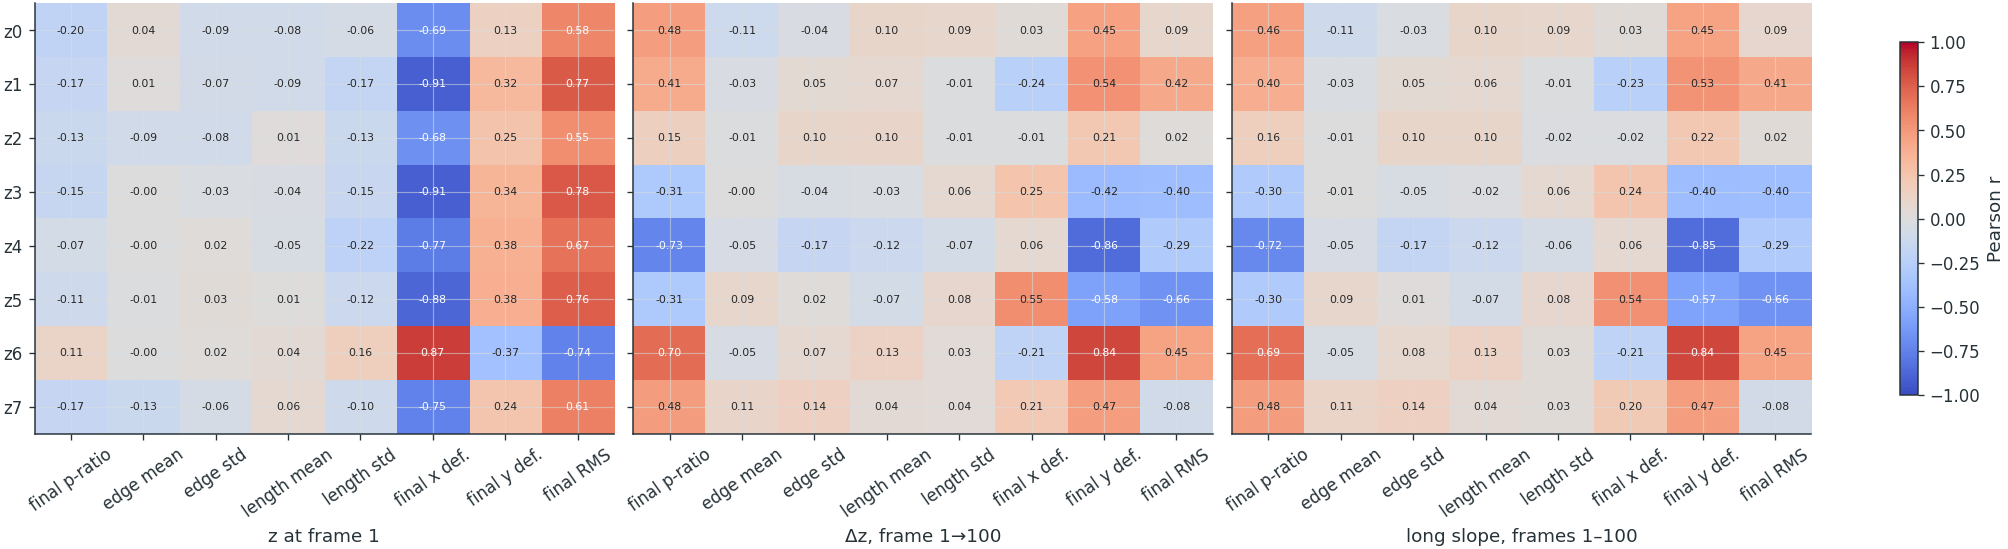

,descriptor,coordinate,target,pearson_r,n_networks
13,z at frame 1,z1,final_x_deformation,-0.9131,100
29,z at frame 1,z3,final_x_deformation,-0.9120,100
102,"Δz, frame 1→100",z4,final_y_deformation,-0.8557,100
166,"long slope, frames 1–100",z4,final_y_deformation,-0.8511,100
182,"long slope, frames 1–100",z6,final_y_deformation,0.8421,100
118,"Δz, frame 1→100",z6,final_y_deformation,0.8413,100
31,z at frame 1,z3,final_rms_displacement,0.7756,100
15,z at frame 1,z1,final_rms_displacement,0.7695,100
96,"Δz, frame 1→100",z4,final_p_ratio,-0.7289,100
160,"long slope, frames 1–100",z4,final_p_ratio,-0.7181,100


In [19]:
def latent_slope(values, start, stop):
    time = np.arange(start, stop + 1, dtype=float)
    time = time - time.mean()
    return (time[:, None] * values[start:stop + 1]).sum(0) / np.square(time).sum()

network_rows = []
for sim_index, (sim, trajectory_z) in enumerate(zip(test_sims, test_z.numpy())):
    edge_values = sim[0].edge_attr[:, -1].detach().cpu().numpy().astype(float)
    long_slope = latent_slope(trajectory_z, 1, TARGET_STEP)
    long_delta = trajectory_z[TARGET_STEP] - trajectory_z[1]
    reference = sim[0].x[:, :2].detach().cpu().numpy()
    final = sim[TARGET_STEP].x[:, :2].detach().cpu().numpy()
    side = directional_side_indices_from_box(sim[0], quantile=0.10)
    width0 = reference[side['right'], 0].mean() - reference[side['left'], 0].mean()
    height0 = reference[side['top'], 1].mean() - reference[side['bottom'], 1].mean()
    width = final[side['right'], 0].mean() - final[side['left'], 0].mean()
    height = final[side['top'], 1].mean() - final[side['bottom'], 1].mean()
    edge_lengths = sim[0].edge_attr[:, 2].detach().cpu().numpy().astype(float)
    row = {
        'sim_index': sim_index, 'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        'mean_edge_property': float(np.mean(edge_values)), 'std_edge_property': float(np.std(edge_values)),
        'mean_reference_edge_length': float(np.mean(edge_lengths)), 'std_reference_edge_length': float(np.std(edge_lengths)),
        'final_x_deformation': float(width - width0), 'final_y_deformation': float(height - height0),
        'final_rms_displacement': float(np.sqrt(np.mean(np.square(final - reference).sum(axis=1)))),
    }
    for coordinate in range(AE_CONFIG['latent_dim']):
        row[f'z{coordinate}_frame1'] = trajectory_z[1, coordinate]
        row[f'z{coordinate}_long_delta'] = long_delta[coordinate]
        row[f'z{coordinate}_long_slope'] = long_slope[coordinate]
    network_rows.append(row)
network_descriptors = pd.DataFrame(network_rows).replace([np.inf, -np.inf], np.nan)
targets = ['final_p_ratio', 'mean_edge_property', 'std_edge_property', 'mean_reference_edge_length', 'std_reference_edge_length', 'final_x_deformation', 'final_y_deformation', 'final_rms_displacement']
feature_groups = {
    'z at frame 1': [f'z{i}_frame1' for i in range(8)],
    f'Δz, frame 1→{TARGET_STEP}': [f'z{i}_long_delta' for i in range(8)],
    f'long slope, frames 1–{TARGET_STEP}': [f'z{i}_long_slope' for i in range(8)],
}
network_corr_rows = []
for descriptor, columns in feature_groups.items():
    for coordinate, column in enumerate(columns):
        for target in targets:
            values = network_descriptors[[column, target]].dropna()
            correlation = np.corrcoef(values[column], values[target])[0, 1] if len(values) >= 3 and values[column].std() > 1e-12 and values[target].std() > 1e-12 else np.nan
            network_corr_rows.append({'descriptor': descriptor, 'coordinate': f'z{coordinate}', 'target': target, 'pearson_r': correlation, 'n_networks': len(values)})
network_correlations = pd.DataFrame(network_corr_rows)
network_descriptors.to_csv(OUTPUT/'network_latent_descriptors.csv', index=False)
network_correlations.to_csv(OUTPUT/'network_latent_correlations.csv', index=False)

target_labels = ['final p-ratio', 'edge mean', 'edge std', 'length mean', 'length std', 'final x def.', 'final y def.', 'final RMS']
print('Network-level Pearson correlations: initial latent state, long latent change, and long latent slope.')
fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.6), sharey=True, constrained_layout=True)
for ax, descriptor in zip(axes, feature_groups):
    pivot = network_correlations[network_correlations.descriptor.eq(descriptor)].pivot(index='coordinate', columns='target', values='pearson_r').reindex([f'z{i}' for i in range(8)])[targets]
    image = ax.imshow(pivot, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set(xlabel=descriptor, xticks=range(len(targets)), xticklabels=target_labels, yticks=range(8), yticklabels=[f'z{i}' for i in range(8)])
    ax.tick_params(axis='x', rotation=35)
    for row_index in range(pivot.shape[0]):
        for column_index in range(pivot.shape[1]):
            value = pivot.iloc[row_index, column_index]
            ax.text(column_index, row_index, '—' if not np.isfinite(value) else f'{value:.2f}', ha='center', va='center', fontsize=6.5, color='white' if np.isfinite(value) and abs(value) > .55 else '0.15')
fig.colorbar(image, ax=axes, label='Pearson r', shrink=.82)
fig.savefig(OUTPUT/'network_level_latent_correlations.png', dpi=240, bbox_inches='tight')
fig.savefig(OUTPUT/'network_level_latent_correlations.pdf', bbox_inches='tight')
plt.show()
ranked_correlations = network_correlations.assign(abs_r=network_correlations.pearson_r.abs()).sort_values('abs_r', ascending=False)
strongest_by_target = ranked_correlations.groupby(['descriptor', 'target'], sort=False).head(2).drop(columns='abs_r')
display(strongest_by_target.round(4))

## Within-trajectory latent tracking

/tmp/ipykernel_2446510/2622589297.py:35: RuntimeWarning: All-NaN slice encountered
  within_summary = within_correlations.groupby(['representation', 'coordinate', 'metric']).pearson_r.agg(mean_r='mean', median_abs_r=lambda x: np.nanmedian(np.abs(x)), n='count').reset_index()


Mean within-trajectory Pearson correlations for latent states and frame-to-frame latent increments.


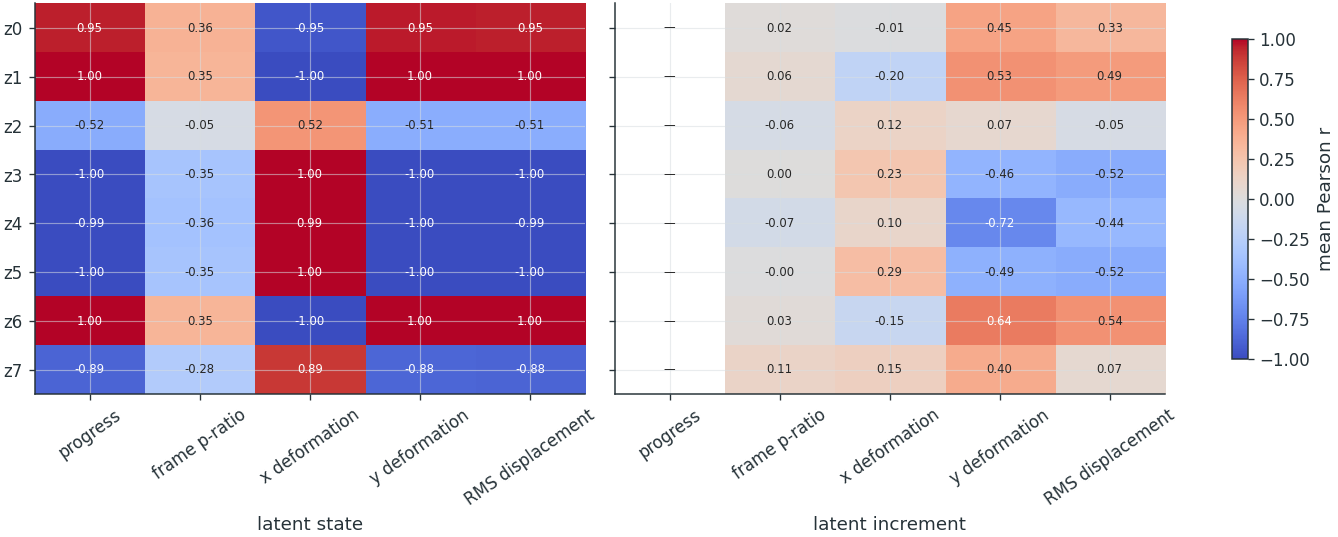

,representation,coordinate,metric,mean_r,median_abs_r,n
0,latent increment,z0,frame_p_ratio,0.0226,0.4369,100
1,latent increment,z0,progress,NaN,NaN,0
2,latent increment,z0,rms_displacement,0.3315,0.6104,100
3,latent increment,z0,x_side_displacement,-0.0141,0.3175,100
4,latent increment,z0,y_side_displacement,0.4531,0.7970,100
...,...,...,...,...,...,...
75,latent state,z7,frame_p_ratio,-0.2814,0.8005,100
76,latent state,z7,progress,-0.8867,0.9978,100
77,latent state,z7,rms_displacement,-0.8842,0.9979,100
78,latent state,z7,x_side_displacement,0.8869,0.9980,100


In [20]:
FRAME_STRIDE = 5
frame_rows = []
for sim_index, (sim, trajectory_z) in enumerate(zip(test_sims, test_z.numpy())):
    side = directional_side_indices_from_box(sim[0], quantile=0.10)
    reference = sim[0].x[:, :2].detach().cpu().numpy()
    width0 = reference[side['right'], 0].mean() - reference[side['left'], 0].mean()
    height0 = reference[side['top'], 1].mean() - reference[side['bottom'], 1].mean()
    for frame in range(0, SPLIT_CONFIG['final_step'] + 1, FRAME_STRIDE):
        current = sim[frame].x[:, :2].detach().cpu().numpy()
        width = current[side['right'], 0].mean() - current[side['left'], 0].mean()
        height = current[side['top'], 1].mean() - current[side['bottom'], 1].mean()
        displacement = current - reference
        row = {
            'sim_index': sim_index, 'frame': frame, 'progress': frame / SPLIT_CONFIG['final_step'],
            'frame_p_ratio': float(calc_p_ratio_rollout_sides(sim, frame, side_idx=side)),
            'x_side_displacement': float(width - width0), 'y_side_displacement': float(height - height0),
            'rms_displacement': float(np.sqrt(np.mean(np.square(displacement).sum(axis=1)))),
        }
        row.update({f'z{i}': float(trajectory_z[frame, i]) for i in range(8)})
        frame_rows.append(row)
frame_latents = pd.DataFrame(frame_rows).replace([np.inf, -np.inf], np.nan)
within_metrics = ['progress', 'frame_p_ratio', 'x_side_displacement', 'y_side_displacement', 'rms_displacement']
delta_latents = frame_latents.copy()
for column in [*[f'z{i}' for i in range(8)], *within_metrics]:
    delta_latents[column] = delta_latents.groupby('sim_index')[column].diff()
within_rows = []
for representation, table in [('latent state', frame_latents), ('latent increment', delta_latents)]:
    for sim_index, trajectory in table.groupby('sim_index'):
        for coordinate in range(8):
            for metric in within_metrics:
                values = trajectory[[f'z{coordinate}', metric]].dropna()
                correlation = np.corrcoef(values[f'z{coordinate}'], values[metric])[0, 1] if len(values) >= 3 and values[f'z{coordinate}'].std() > 1e-12 and values[metric].std() > 1e-12 else np.nan
                within_rows.append({'representation': representation, 'sim_index': sim_index, 'coordinate': f'z{coordinate}', 'metric': metric, 'pearson_r': correlation})
within_correlations = pd.DataFrame(within_rows)
within_summary = within_correlations.groupby(['representation', 'coordinate', 'metric']).pearson_r.agg(mean_r='mean', median_abs_r=lambda x: np.nanmedian(np.abs(x)), n='count').reset_index()
frame_latents.to_csv(OUTPUT/'framewise_test_latents.csv', index=False)
within_correlations.to_csv(OUTPUT/'within_trajectory_correlations.csv', index=False)
within_summary.to_csv(OUTPUT/'within_trajectory_correlation_summary.csv', index=False)

print('Mean within-trajectory Pearson correlations for latent states and frame-to-frame latent increments.')
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5), sharey=True, constrained_layout=True)
for ax, representation in zip(axes, ['latent state', 'latent increment']):
    pivot = within_summary[within_summary.representation.eq(representation)].pivot(index='coordinate', columns='metric', values='mean_r').reindex([f'z{i}' for i in range(8)])[within_metrics]
    image = ax.imshow(pivot, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
    ax.set(xlabel=representation, xticks=range(len(within_metrics)), xticklabels=['progress', 'frame p-ratio', 'x deformation', 'y deformation', 'RMS displacement'], yticks=range(8), yticklabels=[f'z{i}' for i in range(8)])
    ax.tick_params(axis='x', rotation=35)
    for row_index in range(pivot.shape[0]):
        for column_index in range(pivot.shape[1]):
            value = pivot.iloc[row_index, column_index]
            ax.text(column_index, row_index, '—' if not np.isfinite(value) else f'{value:.2f}', ha='center', va='center', fontsize=7, color='white' if np.isfinite(value) and abs(value) > .55 else '0.15')
fig.colorbar(image, ax=axes, label='mean Pearson r', shrink=.82)
fig.savefig(OUTPUT/'within_trajectory_latent_correlations.png', dpi=240, bbox_inches='tight')
fig.savefig(OUTPUT/'within_trajectory_latent_correlations.pdf', bbox_inches='tight')
plt.show()
display(within_summary.round(4))